<a href="https://colab.research.google.com/github/jdeepak-4u/my-new-ai-repo/blob/feature-agent/HandsOn_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install Packages

In [145]:
! pip install -q langchain langchain-openai langgraph langgraph duckduckgo-search wikipedia langchain-community ddgs

In [146]:
!pip -q install --upgrade langchain langgraph langchain-core

In [147]:
!pip -q install langchain faiss-cpu langchain-community langchain-google-genai pypdf requests google-generativeai

In [148]:
!pip install -q langchain_groq

In [149]:
!pip install -q forex-python

In [150]:
!pip -q install fastmcp langchain_mcp_adapters

In [151]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# Import Packages

In [152]:
import pandas as pd
import os
from google.colab import userdata
from typing import List, Dict, Any, Literal
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from fastmcp import FastMCP
import threading

# Set environment variable

In [153]:
os.environ["OPENAI_API_KEY"]=userdata.get('OPENAI_API_KEY')
# llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.5)

In [154]:
os.environ["GOOGLE_API_KEY"] = userdata.get("GEMINI_API_KEY")

In [155]:
os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")

In [156]:
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

# Create Tools

In [157]:
mcp = FastMCP("DemoServer")
@mcp.tool()
def currency_converter(amount: float, from_currency: str, to_currency: str) -> str:
    """Converts currency amounts. Supports USD, INR, EUR, GBP.
    Use this to normalize itinerary costs to the user's budget currency.
    """
    # hardcoded mock rates for stable execution
    rates = {
        "USD": 1.0,
        "INR": 83.5,
        "EUR": 0.92,
        "GBP": 0.78
    }
    try:
        from_curr = from_currency.upper().strip()
        to_curr = to_currency.upper().strip()

        if from_curr not in rates or to_curr not in rates:
            return f"Error: Unsupported currency conversion from {from_curr} to {to_curr}."

        # Convert to base (USD) then to target
        amount_in_usd = amount / rates[from_curr]
        converted_amount = amount_in_usd * rates[to_curr]
        return f"{amount} {from_curr} is approximately {round(converted_amount, 2)} {to_curr}"
    except Exception as e:
        return f"Error performing conversion: {str(e)}"

In [158]:
# START SERVER IN BACKGROUND

def run_server():

    mcp.run(
        transport="streamable-http",
        host="127.0.0.10",
        port=8000
    )


threading.Thread(
    target=run_server,
    daemon=True
).start()

print("Local MCP Server Running")

Local MCP Server Running




╭──────────────────────────────────────────────────────────────────────────────╮
│                                                                              │
│                                                                              │
│                         ▄▀▀ ▄▀█ █▀▀ ▀█▀ █▀▄▀█ █▀▀ █▀█                        │
│                         █▀  █▀█ ▄▄█  █  █ ▀ █ █▄▄ █▀▀                        │
│                                                                              │
│                                                                              │
│                                FastMCP 3.3.1                                 │
│                            https://gofastmcp.com                             │
│                                                                              │
│                  🖥  Server:      DemoServer, 3.3.1                           │
│                  🚀 Deploy free: https://horizon.prefect.io                  │
│                          

In [179]:
from langchain_mcp_adapters.client import MultiServerMCPClient

client = MultiServerMCPClient(
    {
        "demo": {
            "url": "http://127.0.0.10:8000/mcp",
            "transport": "streamable_http",
        }
    }
)
currency_converter = await client.get_tools()

INFO:     127.0.0.1:53264 - "POST /mcp HTTP/1.1" 200 OK
INFO:     127.0.0.1:53276 - "POST /mcp HTTP/1.1" 202 Accepted
INFO:     127.0.0.1:53288 - "GET /mcp HTTP/1.1" 200 OK
INFO:     127.0.0.1:53300 - "POST /mcp HTTP/1.1" 200 OK
INFO:     127.0.0.1:53302 - "DELETE /mcp HTTP/1.1" 200 OK


In [160]:
ddg_search = DuckDuckGoSearchRun()
wikipedia = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())

In [162]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.5,
)

# Bind tools together for the Budget Agent

In [163]:
all_tools = [ddg_search, wikipedia] + currency_converter
llm_with_tools = llm.bind_tools(all_tools)

# Create State

In [164]:
class AgentState(BaseModel):
    user_query: str
    extracted_info: Dict[str, Any] = Field(default_factory=dict)
    itinerary_plan: str = ""
    budget_analysis: str = ""
    status: Literal["pending", "approved", "rejected"] = "pending"
    feedback: str = ""
    retry_count: int = 0

# Schemas for Structured Outputs

In [165]:
class ExtractedInfo(BaseModel):
    destination: str = Field(description="The destination country or city.")
    max_budget: float = Field(description="The maximum numerical budget specified by the user.")
    currency: str = Field(description="The currency code (e.g., USD, INR, EUR).")
    duration_days: int = Field(description="Number of days for the trip.")

class BudgetEvaluation(BaseModel):
    status: Literal["approved", "rejected"] = Field(description="'approved' if total estimated cost <= max_budget, otherwise 'rejected'")
    total_estimated_cost: float = Field(description="The final summed up cost in the user's local currency.")
    feedback: str = Field(description="Detailed breakdown of costs per activity and advice on what to scale down if rejected.")

#Supervsior Agent

In [187]:
async def supervisor_agent(state: AgentState) -> Dict[str, Any]:
    print(f"\n[Supervisor] Processing... (Iteration {state.retry_count + 1}/5)")

    # Step 1: Extracting info if not already done
    if not state.extracted_info:
        parser_llm = llm.with_structured_output(ExtractedInfo)
        extracted = await parser_llm.ainvoke(f"Extract details from this query: {state.user_query}")
        extracted_dict = extracted.model_dump()
    else:
        extracted_dict = state.extracted_info

    # Step 2: Routing or process feedback
    if state.status == "rejected":
        # Forward feedback to Itinerary agent implicitly through the updated state
        print("[Supervisor] Plan was rejected. Forwarding feedback to Itinerary Agent.")
        return {"extracted_info": extracted_dict, "retry_count": state.retry_count + 1}

    return {"extracted_info": extracted_dict}

# Itinerary agent

In [188]:
async def itinerary_agent(state: AgentState) -> Dict[str, Any]:
    print("[Itinerary Agent] Generating/Adjusting travel plan...")

    info = state.extracted_info
    base_prompt = f"Create a detailed day-by-day itinerary for a {info.get('duration_days')} day trip to {info.get('destination')}."

    if state.feedback:
        base_prompt += f"\n\nCRITICAL FEEDBACK FROM PREVIOUS ATTEMPT:\n {state.feedback}\nModify the locations, hotels, or activities to reduce costs drastically to fit the budget of {info.get('max_budget')} {info.get('currency')}."
    else:
        base_prompt += f" Keep in mind the user's total target budget is {info.get('max_budget')} {info.get('currency')}."

    response = await llm.ainvoke(base_prompt)
    return {"itinerary_plan": response.content}

# Budget agent

In [189]:
async def budget_agent(state: AgentState) -> Dict[str, Any]:
    print("[Budget Agent] Analyzing costs using live tools...")
    info = state.extracted_info

    tool_prompt = f"""
    You are an expert financial auditor for travel.
    Review this itinerary:\n{state.itinerary_plan}\n
    1. Use DuckDuckGo search or Wikipedia to find realistic, current prices for the hotels, flights, or activities mentioned.
    2. Use the currency_converter tool to convert those costs into the user's native currency: {info.get('currency')}.
    3. Calculate the total cost.
    4. Provide your final analysis. You MUST output your final conclusion using structured formatting.
    """

    # Let the LLM use tools autonomously
    message = await llm_with_tools.ainvoke(tool_prompt)

    # Simple tool execution loop inside the node
    tool_calls = message.tool_calls
    if tool_calls:
        available_tools = {t.name: t for t in all_tools}
        tool_outputs = []
        for call in tool_calls:
            tool_obj = available_tools[call['name']]
            print(f"   -> Budget Agent calling tools: {call['name']} with {call['args']}")
            output = await tool_obj.ainvoke(call['args'])
            tool_outputs.append(f"Tool {call['name']} result: {output}")

        # Feed tool outputs back to finalize judgment
        final_prompt = f"{tool_prompt}\n\nTool Results discovered:\n" + "\n".join(tool_outputs) + "\nNow formulate your final structured approval or rejection."
    else:
        final_prompt = tool_prompt

    # Force structured evaluation output
    evaluator = llm.with_structured_output(BudgetEvaluation)
    result = await evaluator.ainvoke(final_prompt)

    print(f"[Budget Agent] Result: {result.status.upper()} | Est Cost: {result.total_estimated_cost} {info.get('currency')}")

    return {
        "status": result.status,
        "feedback": result.feedback if result.status == "rejected" else "Approved!",
        "budget_analysis": f"Total Estimated: {result.total_estimated_cost} {info.get('currency')}.\nDetails: {result.feedback}"
    }

# Routing logic

In [190]:
def route_next(state: AgentState):
    if state.status == "approved":
        print("\n[Routing] Plan Approved! Sending to User.")
        return END
    elif state.retry_count >= 5:
        print("\n[Routing] Hit maximum retry limit. Terminating loop with latest plan.")
        return END
    else:
        print(f"\n[Routing] Loop continuous. Returning to Supervisor.")
        return "supervisor"

# Creating a Workflow

In [191]:
workflow = StateGraph(AgentState)

# Add Nodes
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("itinerary_agent", itinerary_agent)
workflow.add_node("budget_agent", budget_agent)

# Setup Connections
workflow.add_edge(START, "supervisor")
workflow.add_edge("supervisor", "itinerary_agent")
workflow.add_edge("itinerary_agent", "budget_agent")

# Add conditional routing after budget check
workflow.add_conditional_edges(
    "budget_agent",
    route_next,
    {
        "supervisor": "supervisor",
        END: END
    }
)

# Compile the application
app = workflow.compile()

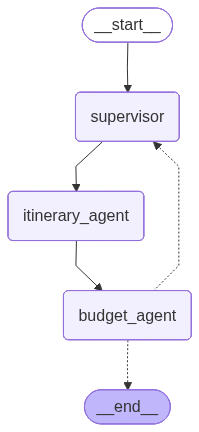

In [192]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [193]:
query = "I want a luxury 3-day trip package to Paris staying at The Ritz with fine dining. My total budget is 1500 USD."

print(f"Starting Multi-Agent Planner for query: '{query}'")
final_state = await app.ainvoke({"user_query": query})


status = final_state.get('status', 'pending')
retry_count = final_state.get('retry_count', 0)
itinerary_plan = final_state.get('itinerary_plan', 'No itinerary generated.')
budget_analysis = final_state.get('budget_analysis', 'No analysis available.')

print("\n" + "-------"*10)
print("FINAL OUTPUT TO USER:")
print("------"*40)
print(f"Status: {str(status).upper()}")
print(f"Total Iterations: {retry_count}\n")
print("--- ITINERARY ---")
print(itinerary_plan)
print("\n--- BUDGET ANALYSIS ---")
print(budget_analysis)

Starting Multi-Agent Planner for query: 'I want a luxury 3-day trip package to Paris staying at The Ritz with fine dining. My total budget is 1500 USD.'

[Supervisor] Processing... (Iteration 1/5)
[Itinerary Agent] Generating/Adjusting travel plan...
[Budget Agent] Analyzing costs using live tools...
   -> Budget Agent calling tools: currency_converter with {'amount': 160, 'from_currency': 'EUR', 'to_currency': 'USD'}
INFO:     127.0.0.1:50240 - "POST /mcp HTTP/1.1" 200 OK
INFO:     127.0.0.1:50242 - "POST /mcp HTTP/1.1" 202 Accepted
INFO:     127.0.0.1:50254 - "GET /mcp HTTP/1.1" 200 OK
INFO:     127.0.0.1:50258 - "POST /mcp HTTP/1.1" 200 OK
INFO:     127.0.0.1:50274 - "POST /mcp HTTP/1.1" 200 OK
INFO:     127.0.0.1:50290 - "DELETE /mcp HTTP/1.1" 200 OK
   -> Budget Agent calling tools: currency_converter with {'amount': 60, 'from_currency': 'EUR', 'to_currency': 'USD'}
INFO:     127.0.0.1:50306 - "POST /mcp HTTP/1.1" 200 OK
INFO:     127.0.0.1:50314 - "POST /mcp HTTP/1.1" 202 Accepte